# 06. 정책 비교 실험 — 본론

저장된 확률을 읽어 **P0~P6 정책 사다리**를 비교한다.
모델을 재학습하지 않으므로 파라미터를 바꿔가며 빠르게 반복할 수 있다.

| # | 정책 | 답하는 질문 |
|---|---|---|
| P0 | 전건 승인 | 무개입 기준선 |
| P1 | 규칙 기반 | ML이 규칙보다 나은가 |
| P2 | 단일 임계값 | 모델의 순수 기여 |
| P3 | 비용 기반 임계값 | 비용에서 유도하면 나아지는가 |
| P4 | + 금액 의존 | 고액/소액 차등이 가치 있나 |
| P5 | + 보류 (예산 $B$) | 검토 인력의 한계 가치 |
| P6 | + 추가 인증 | 추가 인증 도입이 정당한가 |

**인접 행의 차이가 곧 그 요소의 기여도**다. 개선이 멈추는 지점도 발견이다.

> ⚠️ P5·P6은 데이터에 없는 파라미터(검토 정확도, 인증 통과율)에 의존한다.
> 이 절의 결과는 **가정 위에서 도출된 것**이며, 민감도 분석으로 다룬다.

In [1]:
import sys
from pathlib import Path

# src/ 를 import 경로에 추가 (uv pip install -e . 를 했다면 불필요)
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 운영체제별 폰트 설정 (예: 윈도우 맑은 고딕, 맥 애플고딕)
import matplotlib.font_manager as fm
import platform

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 110

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    # Colab의 경우 나눔고딕 설치 후 적용 필요
    plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

from frauddetectionreport import config, evaluate, policy
from frauddetectionreport.costs import Action, CostParams, DEFAULT_PARAMS, block_threshold

pred = pd.read_parquet(config.PREDICTIONS_PARQUET)

# test 전반: 정책 선택용 / 후반: 확인용 (선택 과적합 방지)
sel = pred[pred.half == "a_select"].reset_index(drop=True)
cfm = pred[pred.half == "b_confirm"].reset_index(drop=True)

print(f"선택용 {len(sel):,}건 (사기율 {sel.is_fraud.mean():.3%})")
print(f"확인용 {len(cfm):,}건 (사기율 {cfm.is_fraud.mean():.3%})")

선택용 59,054건 (사기율 3.134%)
확인용 59,054건 (사기율 3.747%)


## 1. 비용 파라미터 — 가정의 명시

`TransactionAmt`는 대회 호스트 설명상 USD 결제금액이다. 다만 나머지 비용은
데이터에 없는 가정이므로 절대 비용 결론 대신 상대 비교와 민감도를 본다.

아래 값은 확정된 것이 아니라 **출발점**이며, §4에서 넓게 흔들어본다.

In [2]:
sel_day = (sel.TransactionDT // 86400).astype(int).to_numpy()
cfm_day = (cfm.TransactionDT // 86400).astype(int).to_numpy()
daily_volume = pd.Series(sel_day).value_counts()
daily_budget = max(1, int(daily_volume.median() * 0.01))
P = DEFAULT_PARAMS.with_(review_budget=daily_budget)  # 일별 거래의 약 1%

print(f"{'파라미터':22s} {'값':>10s}   설명")
print("-" * 70)
for f_ in P.__dataclass_fields__.values():
    print(f"{f_.name:22s} {str(getattr(P, f_.name)):>10s}")
print(f"\nauth_gap (s_l - s_f) = {P.auth_gap:.2f}  (두 통과율은 §4-3에서 함께 변화)")

파라미터                            값   설명
----------------------------------------------------------------------
chargeback_fee               15.0
margin                       0.02
false_block_penalty          25.0
review_cost                   3.0
review_delay_cost             1.0
review_catch_rate            0.95
auth_pass_fraud              0.15
auth_pass_legit               0.9
auth_friction                 0.5
review_budget                  27

auth_gap (s_l - s_f) = 0.75  (두 통과율은 §4-3에서 함께 변화)


### 임계값은 비용에서 유도된다

기획서 §1.4: 임계값은 튜닝 대상이 아니라 **유도 결과**이며,
금액에 대해 **감소**한다.

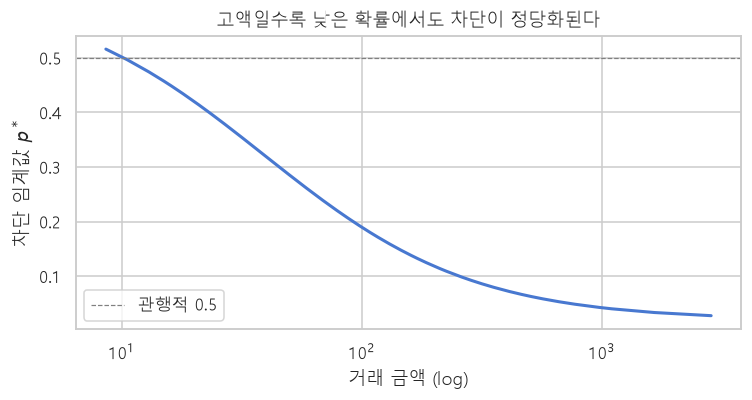

In [3]:
grid = np.quantile(sel.amount, np.linspace(0.01, 0.999, 200))
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(grid, block_threshold(grid, P), lw=2)
ax.axhline(0.5, ls="--", c="gray", lw=0.8, label="관행적 0.5")
ax.set_xscale("log"); ax.set_xlabel("거래 금액 (log)")
ax.set_ylabel("차단 임계값 $p^*$"); ax.legend()
ax.set_title("고액일수록 낮은 확률에서도 차단이 정당화된다")
plt.tight_layout(); plt.show()

## 2. 핵심 결과표 ← 보고서의 결론

절대 금액은 가정에 의존하므로 **P0 대비 절감률**로 정규화해 보고한다.

In [ ]:
policies = policy.build_ladder(
    sel.p.to_numpy(), sel.is_fraud.to_numpy(), reference_amount=sel.amount.mean()
)

result = evaluate.compare_policies(
    policies, sel.p.to_numpy(), sel.amount.to_numpy(), sel.is_fraud.to_numpy(), P,
    review_group=sel_day,
)

main_cols = ["total", "saving_vs_p0",
             "fraud_loss", "false_block_loss", "review_cost", "auth_friction",
             "block_rate", "false_block_rate", "fraud_recall_amount",
             "n_review", "n_auth"]
display(result[main_cols].style.format({
    "total": "{:,.0f}", "saving_vs_p0": "{:.2%}",
    "fraud_loss": "{:,.0f}", "false_block_loss": "{:,.0f}",
    "review_cost": "{:,.0f}", "auth_friction": "{:,.0f}",
    "block_rate": "{:.2%}", "false_block_rate": "{:.2%}", "fraud_recall_amount": "{:.2%}",
    "n_review": "{:,}", "n_auth": "{:,}",
}).background_gradient(subset=["saving_vs_p0"], cmap="Greens"))

# 분해 항의 합은 총비용과 정확히 일치한다 (검산)
parts_sum = result[["fraud_loss", "false_block_loss", "review_cost", "auth_friction"]].sum(axis=1)
assert np.allclose(parts_sum, result["total"]), "비용 분해 불일치"


### 비용 분해 — 개선의 출처

총비용만 보면 어디서 이득이 났는지 모른다.
P3→P4에서 비용이 줄었을 때 **사기 손실이 준 것인지 정상 차단이 준 것인지**가
여기서 드러난다.

분해는 행동이 아니라 **비용의 성격**을 기준으로 한다. 예컨대 추가 인증의 비용은
사기 쪽에서 '인증을 통과당해 놓친 손실', 정상 쪽에서 '인증에 막혀 이탈한 손실'과
'마찰'로 나뉜다. 행동 단위로 뭉뚱그리면 P6의 비용 구성이 실제와 어긋나 보인다.
네 항의 합은 총비용과 정확히 일치한다.


In [ ]:
parts = result[["fraud_loss", "false_block_loss", "review_cost", "auth_friction"]]
fig, ax = plt.subplots(figsize=(10, 4))
parts.plot(kind="bar", stacked=True, ax=ax,
           color=["crimson", "steelblue", "goldenrod", "mediumpurple"])
ax.set_ylabel("비용"); ax.set_xlabel("")
ax.set_title("정책별 비용 구성")
ax.legend(["사기 손실", "정상 차단 손실", "검토 비용", "인증 마찰"])
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()


In [ ]:
# 사다리 한 칸당 개선폭 — 각 요소의 기여도
step = result["total"].diff().to_frame("비용 변화")
step["개선률"] = -result["total"].pct_change()
display(step.style.format({"비용 변화": "{:,.0f}", "개선률": "{:.2%}"}))

> **02에서 세운 예측과 대조한다.**
> 손실이 소수 고액 거래에 집중되어 있었다면 P3→P4의 개선폭이 클 것이고,
> 고르게 퍼져 있었다면 작을 것이다. 예측이 맞았는지 확인하는 것이
> 보고서의 논리적 완결성을 만든다.

## 3. 모델 품질과 총비용의 관계

**AUC와 총비용의 순위가 불일치할 수 있다.** LGBM(보정됨) vs LR vs 보정 전 확률을
같은 정책으로 비교한다. AUC가 낮아도 보정이 잘 된 확률이 총비용에서 이긴다면,
그것이 이 보고서의 가장 중요한 발견이다.

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

rows = []
for name, pr in [("LGBM 보정 후", sel.p), ("LGBM 가중·보정 후", sel.p_weighted),
                 ("LGBM 보정 전", sel.p_raw), ("로지스틱 회귀 보정 후", sel.p_lr)]:
    pr = pr.to_numpy()
    r = evaluate.evaluate_policy(
        policy.AmountAwareThreshold(), pr, sel.amount.to_numpy(), sel.is_fraud.to_numpy(), P
    )
    rows.append({
        "확률": name,
        "ROC-AUC": roc_auc_score(sel.is_fraud, pr),
        "PR-AUC": average_precision_score(sel.is_fraud, pr),
        "ECE": evaluate.calibration_error(sel.is_fraud.to_numpy(), pr),
        "총비용 (P4)": r["total"],
    })
q = pd.DataFrame(rows).set_index("확률")
q["비용 순위"] = q["총비용 (P4)"].rank().astype(int)
q["AUC 순위"] = q["ROC-AUC"].rank(ascending=False).astype(int)
display(q.style.format({"ROC-AUC": "{:.4f}", "PR-AUC": "{:.4f}",
                        "ECE": "{:.4f}", "총비용 (P4)": "{:,.0f}"}))

## 4. 민감도 분석

P5·P6은 가정에 의존한다. **결론은 '이 정책이 최적'이 아니라
'조건 X에서 P5가 P4를 이긴다'는 형태여야 하고**, 그 역전점을 찾는다.

### 4-1. 오차단 페널티 $L$ — 가장 불확실한 파라미터

카드가 막힌 고객의 이탈 손실은 데이터에 전혀 기록되지 않는다.

In [ ]:
%%time
L_grid = np.linspace(0, 200, 21)
sens_L = evaluate.sensitivity(
    policies, sel.p.to_numpy(), sel.amount.to_numpy(), sel.is_fraud.to_numpy(),
    P, "false_block_penalty", L_grid, review_group=sel_day,
)

fig, ax = plt.subplots(figsize=(9, 4.2))
for name, g in sens_L.groupby("policy"):
    ax.plot(g["false_block_penalty"], g["saving_vs_p0"], "o-", ms=3, label=name)
ax.set_xlabel("오차단 페널티 $L$"); ax.set_ylabel("P0 대비 절감률")
ax.legend(fontsize=8, ncol=2); ax.set_title("오차단 비용에 대한 정책 안정성")
plt.tight_layout(); plt.show()

### 4-2. 검토 예산 $B$ — 검토 인력의 한계 가치

"검토자를 몇 명 더 뽑으면 얼마나 이득인가"에 대한 답이다.
곡선이 평평해지는 지점이 **인력 증원의 한계효용이 사라지는 지점**이다.

In [ ]:
%%time
B_grid = [0, 10, 25, 50, 100, 200, 400, 800]
rows = []
for B in B_grid:
    p_ = P.with_(review_budget=B)
    for pol in [policy.AmountAwareThreshold(), policy.WithReview(), policy.FullPolicy()]:
        r = evaluate.evaluate_policy(pol, sel.p.to_numpy(), sel.amount.to_numpy(),
                                     sel.is_fraud.to_numpy(), p_, review_group=sel_day)
        rows.append({"B": B, "policy": pol.name, "total": r["total"],
                     "n_review": r["n_review"]})
sens_B = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 4))
for name, g in sens_B.groupby("policy"):
    ax.plot(g["B"], g["total"], "o-", label=name)
ax.set_xlabel("검토 예산 $B$ (건)"); ax.set_ylabel("총비용")
ax.set_xscale("symlog"); ax.legend(); ax.set_title("검토 인력의 한계 가치")
plt.tight_layout(); plt.show()

# 일일 검토 슬롯 1건 추가가 선택 기간 전체에서 아끼는 비용
mb = sens_B[sens_B.policy == "P5_review"].set_index("B")["total"]
print("\n일일 검토 슬롯 1건 추가당 선택 기간 전체 한계 절감액:")
print((-mb.diff() / pd.Series(B_grid, index=B_grid).diff()).round(2).to_string())

### 4-3. 정상·사기 인증 통과율 — P6의 정당성

$s_l-s_f$가 클수록 인증의 변별력은 높지만 비용은 두 통과율에 각각 의존한다.
따라서 격차 하나로 축약하지 않고 $(s_l, s_f)$ 조합별로 P6과 P5를 비교한다.

In [ ]:
%%time
rows = []
for s_l in np.linspace(0.75, 0.99, 7):
    for s_f in np.linspace(0.0, 0.50, 6):
        if s_f >= s_l:
            continue
        p_ = P.with_(auth_pass_legit=s_l, auth_pass_fraud=s_f)
        vals = {}
        for pol in [policy.WithReview(), policy.FullPolicy()]:
            r = evaluate.evaluate_policy(
                pol, sel.p.to_numpy(), sel.amount.to_numpy(),
                sel.is_fraud.to_numpy(), p_, review_group=sel_day,
            )
            vals[pol.name] = r
        rows.append({"s_l": s_l, "s_f": s_f,
                     "P6_saving_vs_P5": vals["P5_review"]["total"] - vals["P6_full"]["total"],
                     "n_auth": vals["P6_full"]["n_auth"]})
sens_A = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
saving_grid = sens_A.pivot(index="s_l", columns="s_f", values="P6_saving_vs_P5")
auth_grid = sens_A.pivot(index="s_l", columns="s_f", values="n_auth")
sns.heatmap(saving_grid, center=0, cmap="RdYlGn", ax=axes[0])
sns.heatmap(auth_grid, cmap="Blues", ax=axes[1])
axes[0].set_title("P6의 P5 대비 비용 절감(+)")
axes[1].set_title("P6 인증 요구 건수")
for ax in axes:
    ax.set_xlabel("사기 인증 통과율 $s_f$"); ax.set_ylabel("정상 인증 통과율 $s_l$")
plt.tight_layout(); plt.show()

## 5. 공정성 점검

총비용이 낮아도 **특정 집단이 체계적으로 과차단되면 채택할 수 없다.**
02에서 확인한 세그먼트별 사기율 격차가 오차단으로 이어지는지 본다.

In [ ]:
best = policy.WithReview()
act = best.decide(sel.p.to_numpy(), sel.amount.to_numpy(), P, review_group=sel_day)

for col in ["ProductCD", "DeviceType", "card4", "card6"]:
    if col not in sel.columns:
        continue
    t = evaluate.fairness_check(act, sel.is_fraud.to_numpy(), sel[col].to_numpy())
    print(f"\n=== {col} ===")
    display(t.style.format({"fraud_rate": "{:.3%}", "false_block_rate": "{:.3%}",
                            "auth_rate": "{:.2%}"}))

> 세그먼트 간 `false_block_rate` 격차가 크다면, 총비용이 낮더라도
> 운영상 수용 불가능할 수 있다. 보고서 §6에서 이를 논의한다.

## 6. 확인용 구간 검증 ← 정책 선택 과적합 방지

여기까지 **선택용 구간**에서 정책을 비교했다. 그 중 최고를 고르는 순간
그 구간에 과적합된다. **확인용 구간(더 나중 시점)에서 재현되는지** 본다.

재현되지 않으면 드리프트가 있다는 뜻이고, 그것 자체가 중요한 발견이다.

In [ ]:
result_cfm = evaluate.compare_policies(
    policies, cfm.p.to_numpy(), cfm.amount.to_numpy(), cfm.is_fraud.to_numpy(), P,
    review_group=cfm_day,
)

side = pd.DataFrame({
    "선택용 절감률": result["saving_vs_p0"],
    "확인용 절감률": result_cfm["saving_vs_p0"],
})
side["차이"] = side["확인용 절감률"] - side["선택용 절감률"]
display(side.style.format("{:.2%}").background_gradient(subset=["차이"], cmap="RdYlGn"))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(side))
ax.bar(x - 0.2, side["선택용 절감률"], 0.4, label="선택용 (앞 기간)")
ax.bar(x + 0.2, side["확인용 절감률"], 0.4, label="확인용 (뒤 기간)")
ax.set_xticks(x); ax.set_xticklabels(side.index, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("P0 대비 절감률"); ax.legend()
ax.set_title("정책 성능이 시간에 걸쳐 유지되는가")
plt.tight_layout(); plt.show()

## 7. 결론 — 조건부 권고

이 보고서의 결론은 "이 정책이 최적"이 아니라 **조건부 권고**다.

아래 표를 §4의 민감도 분석 결과로 채운다.

| 조건 | 권고 정책 | 근거 |
|---|---|---|
| 검토 인력 없음 | P4 (금액 의존 임계값) | §2 결과표 |
| 검토 예산 $B \geq$ ? | P5 | §4-2 한계 가치 곡선 |
| 인증 통과율 조합 $(s_l,s_f)$이 유리한 영역 | P6 | §4-3 민감도 표 |
| 오차단 비용 $L$ 이 매우 큰 경우 | ? | §4-1 |

### 한계 (보고서 §7)

- **P5·P6은 가정 위의 결과**다. 검토 정확도와 인증 통과율은 데이터에 없다.
- `uid`는 소유자의 **추정**이며 검증할 정답이 없다.
- 거래금액은 USD지만 나머지 비용 파라미터가 가정이라 절대 비용 결론은 제한된다.
- 실시간 서빙, 계정·기기 그래프, 피드백 루프는 다루지 않았다 (기획서 §6).